
# ---
# ## Exploratory Data Analysis (EDA)
# ### American Express — EMV Chip Transition Risk Assessment
# ### ALY6130 Risk Management Analytics | Winter 2026
#
# This notebook explores the risk register data before any
# modeling is applied. The goal is to understand the distribution
# of risk scores, identify patterns, and confirm the data is
# ready for qualitative and quantitative analysis.
# ---


# ---
# ### Step 1 — Load the Data
#
# We build the risk register directly from our Assignment 3
# data since we do not have an external CSV file.
# The data comes from the American Express EMV risk assessment
# conducted using the risk calculation sheet.

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Risk register data
data = {
    'Risk #':           ['R-001', 'R-002', 'R-003', 'R-004', 'R-005', 'R-006'],
    'Risk Type':        ['Financial', 'Operational', 'Competitive',
                         'Reputational', 'Legal/Compliance', 'Operational'],
    'Likelihood Score': [7, 7, 9, 5, 7, 7],
    'Impact Score':     [8, 6, 8, 8, 6, 6],
    'Risk Score':       [56, 42, 72, 40, 42, 42],
    'Priority':         ['HIGH', 'MEDIUM', 'HIGH', 'MEDIUM', 'MEDIUM', 'MEDIUM']
}

df = pd.DataFrame(data)

print("=== RISK REGISTER OVERVIEW ===\n")
print(df.to_string(index=False))




=== RISK REGISTER OVERVIEW ===

Risk #        Risk Type  Likelihood Score  Impact Score  Risk Score Priority
 R-001        Financial                 7             8          56     HIGH
 R-002      Operational                 7             6          42   MEDIUM
 R-003      Competitive                 9             8          72     HIGH
 R-004     Reputational                 5             8          40   MEDIUM
 R-005 Legal/Compliance                 7             6          42   MEDIUM
 R-006      Operational                 7             6          42   MEDIUM



# ---
# ### Step 2 — Basic Data Summary
#
# We look at the shape of the data and basic descriptive
# statistics to understand the range and distribution of
# likelihood, impact, and risk scores.
# ---

In [2]:



# ============================================================
# CELL 5 — CODE
# ============================================================

print("=== DATA SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("=== DESCRIPTIVE STATISTICS ===\n")
print(df[['Likelihood Score', 'Impact Score', 'Risk Score']].describe().round(2))




=== DATA SHAPE ===
Rows: 6, Columns: 6

=== DESCRIPTIVE STATISTICS ===

       Likelihood Score  Impact Score  Risk Score
count              6.00           6.0         6.0
mean               7.00           7.0        49.0
std                1.26           1.1        12.7
min                5.00           6.0        40.0
25%                7.00           6.0        42.0
50%                7.00           7.0        42.0
75%                7.00           8.0        52.5
max                9.00           8.0        72.0


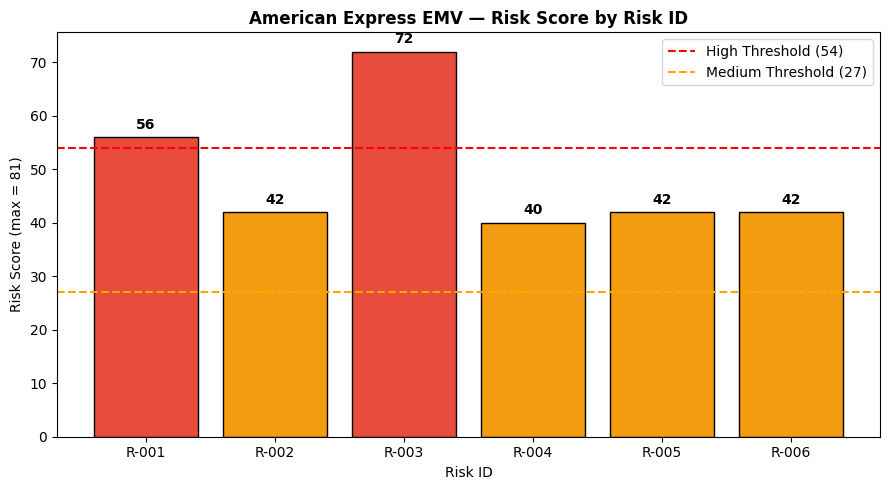

In [3]:
# ============================================================
# CELL 6 — MARKDOWN
# ============================================================
# ---
# ### Step 3 — Risk Score Distribution
#
# This bar chart shows the risk score for each risk.
# The red dashed line marks the High risk threshold (score = 54).
# Any bar above this line is a High priority risk.
# ---


# ============================================================
# CELL 7 — CODE
# ============================================================

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if p == 'HIGH' else '#f39c12' for p in df['Priority']]
bars = plt.bar(df['Risk #'], df['Risk Score'], color=colors, edgecolor='black')

plt.axhline(y=54, color='red', linestyle='--', linewidth=1.5, label='High Threshold (54)')
plt.axhline(y=27, color='orange', linestyle='--', linewidth=1.5, label='Medium Threshold (27)')

for bar, score in zip(bars, df['Risk Score']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1, str(score),
             ha='center', va='bottom', fontweight='bold')

plt.title('American Express EMV — Risk Score by Risk ID', fontweight='bold')
plt.xlabel('Risk ID')
plt.ylabel('Risk Score (max = 81)')
plt.legend()
plt.tight_layout()
plt.show()





# ### Step 4 — Likelihood vs Impact Scatter Plot
#
# This scatter plot shows where each risk sits based on its
# likelihood and impact scores. Risks in the top right corner
# are the most critical as they have both high likelihood
# and high impact.
# ---

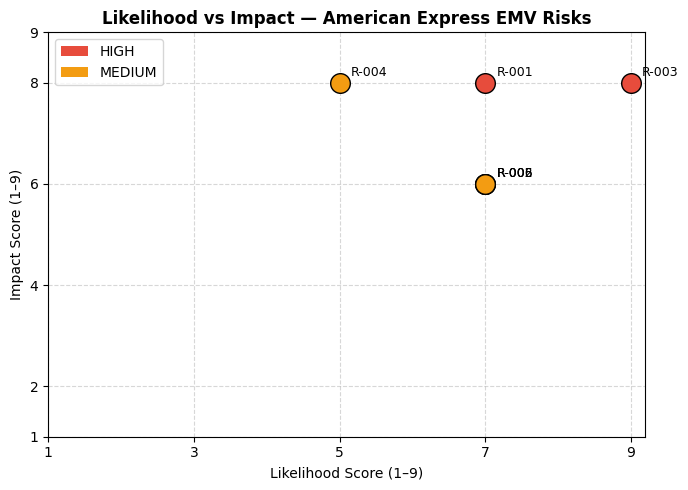

In [4]:



# ============================================================
# CELL 9 — CODE
# ============================================================

plt.figure(figsize=(7, 5))

for _, row in df.iterrows():
    color = '#e74c3c' if row['Priority'] == 'HIGH' else '#f39c12'
    plt.scatter(row['Likelihood Score'], row['Impact Score'],
                color=color, s=200, edgecolor='black', zorder=5)
    plt.annotate(row['Risk #'],
                 (row['Likelihood Score'], row['Impact Score']),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

plt.title('Likelihood vs Impact — American Express EMV Risks', fontweight='bold')
plt.xlabel('Likelihood Score (1–9)')
plt.ylabel('Impact Score (1–9)')
plt.xticks([1, 3, 5, 7, 9])
plt.yticks([1, 2, 4, 6, 8, 9])
plt.grid(True, linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='HIGH'),
                   Patch(facecolor='#f39c12', label='MEDIUM')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()





# ### Step 5 — Risk Type Breakdown
#
# This chart shows how the 6 risks are distributed across
# different risk categories. Operational risk appears twice,
# reflecting the complexity of the EMV transition on
# day-to-day operations.
# ---

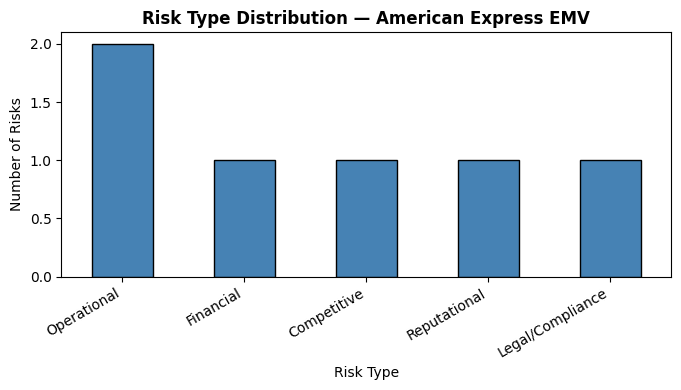

In [5]:



# ============================================================
# CELL 11 — CODE
# ============================================================

risk_type_counts = df['Risk Type'].value_counts()

plt.figure(figsize=(7, 4))
risk_type_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Risk Type Distribution — American Express EMV', fontweight='bold')
plt.xlabel('Risk Type')
plt.ylabel('Number of Risks')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()





# ### Step 6 — Priority Distribution
#
# This pie chart shows the proportion of High vs Medium risks.
# There are no Low risks in this assessment, which confirms
# that the EMV chip transition posed a consistently elevated
# level of risk for American Express across all categories.
# ---


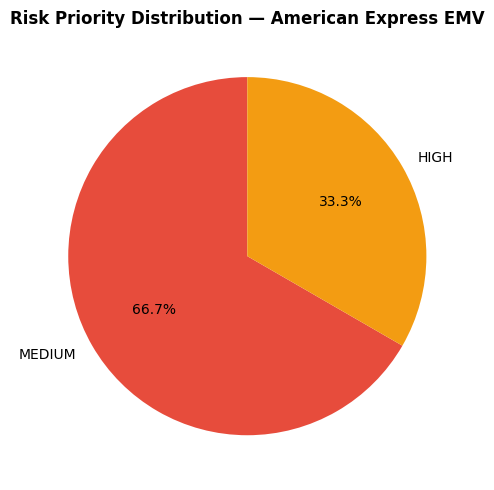

In [7]:


priority_counts = df['Priority'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(priority_counts,
        labels=priority_counts.index,
        autopct='%1.1f%%',
        colors=['#e74c3c', '#f39c12'],
        startangle=90)
plt.title('Risk Priority Distribution — American Express EMV', fontweight='bold')
plt.tight_layout()
plt.show()





# ### EDA Summary
#
# The exploratory analysis of the American Express EMV risk
# register reveals the following key findings:
#
# 1. The dataset contains 6 risks across 5 risk categories.
#
# 2. Risk scores range from 40 (R-004, Reputational) to
#    72 (R-003, Competitive), with a mean score of 49.
#
# 3. Two risks (R-001 and R-003) are classified as HIGH
#    priority. The remaining four are MEDIUM priority.
#    No risks fall in the LOW category, indicating a
#    consistently elevated risk environment.
#
# 4. The scatter plot confirms R-003 (Competitive) is the
#    most critical risk, sitting at maximum likelihood (9)
#    and high impact (8).
#
# 5. Operational risks appear twice, reflecting the broad
#    impact of the EMV transition on day-to-day operations.
#
# These findings provide the foundation for the qualitative
# and quantitative analysis conducted in the subsequent
# notebooks.
# ---

---
# ### References
#
# EMV Connection. (n.d.). EMV migration driven by payment brand
# milestones. https://www.emv-connection.com/emv-migration-driven-by-payment-brand-milestones/
#
# Fitzgerald, K. (2016). Why EMV failed to meet terminal makers'
# expectations. American Banker.
# https://www.americanbanker.com/payments/news/why-emv-failed-to-meet-terminal-makers-expectations
#
# Pape, C. (2025). Visa, Mastercard settle merchant suit for
# nearly $200M. American Banker.
# https://www.americanbanker.com/payments/news/visa-mastercard-settle-merchant-suit-for-nearly-200m
#
# COSO. (2017). Enterprise risk management: Integrating with
# strategy and performance. Committee of Sponsoring Organizations
# of the Treadway Commission. https://www.coso.org/guidance-erm
#
# Jalilvand, A., & Moorthy, S. (2023). Triangulating risk profile
# and risk assessment: A case study of implementing enterprise
# risk management system. Journal of Risk and Financial Management,
# 16(11), 473. https://doi.org/10.3390/jrfm16110473